# Ovarian Cancer Blood Methylation Classifier
## UK Ovarian Cancer Population Study (UKOPS) — GSE19711

**Two classification models from whole blood DNA methylation:**

| Model | Task | n | Balanced Acc | p-value |
|---|---|---|---|---|
| **Model 1** | OC detection (Control vs Pre-treatment OC) | 405 | 0.753 | 0.001 |
| **Model 2** | OC stage (Early I+II vs Late III+IV) | 129 | 0.465 | 0.341 |

**Platform:** Illumina Infinium 27k Human DNA Methylation BeadChip v1.2  
**Tissue:** Peripheral whole blood (postmenopausal women)  

### Key Design Decisions
- **Post-treatment cases excluded** — chemotherapy alters blood methylation independently of cancer biology, inflating performance if included
- **Pre-treatment only** — 131 cases whose blood was drawn at diagnosis before any treatment
- **Leak-free feature selection** — `TTestSelector` fits exclusively on the training fold of each CV split, preventing the test sample from influencing probe selection
- **Outlier removal** — 2 technical outliers (PC1 > 3 SD from mean) removed from stage model before modelling
- **Covariate analysis** — age, batch, and bisulfite conversion investigated; batch imbalance noted (batches 10 and 11 contain controls only)

### Negative Result (Model 2)
OC stage is **not detectable** from blood methylation (balanced accuracy 0.465, below chance; p=0.341). This is a scientifically valid negative result consistent with the biological expectation that stage is a spatial characteristic of tumour spread, not reflected in circulating blood methylation.

---

### Pipeline
1. Setup and helper functions
2. Data loading (GSE19711)
3. Metadata extraction (14 characteristics columns)
4. Label assignment — pre-treatment filtering
5. Quality control — missing value filtering
6. Model 1 — OC detection (leak-free 5-fold CV)
7. Model 2 — OC stage (outlier removal + leak-free LOO-CV)
8. Covariate analysis (age, batch, bisulfite conversion)
9. Leakage quantification
10. Panel summary

---
## 1. Setup

In [1]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
                                      cross_val_score, cross_val_predict,
                                      permutation_test_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = "/Users/aniketnaik/Desktop/Research Projects/Methylomic_Data_Analysis"
OC_DIR   = os.path.join(BASE_DIR, "Ovarian_Cancer_Data")
SAVE_DIR = os.path.join(BASE_DIR, "preeclampsia_data/saved_models")
OC_FILE  = os.path.join(OC_DIR, "GSE19711_series_matrix.txt.gz")
os.makedirs(OC_DIR,   exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Data file exists: {os.path.exists(OC_FILE)}")
print(f"File size: {os.path.getsize(OC_FILE)/1e6:.1f} MB")

Data file exists: True
File size: 61.1 MB


---
## 2. Helper Functions

In [2]:
def load_series_matrix(filepath):
    """Load beta value matrix from a GEO series matrix file."""
    beta = pd.read_csv(
        filepath, sep="\t", comment="!", index_col=0,
        compression="gzip" if filepath.endswith(".gz") else None
    )
    return beta[~beta.index.isna()]


def extract_metadata_gz_multi(filepath):
    """
    Extract metadata from a GEO series matrix file.
    Handles multiple !Sample_characteristics_ch1 rows by appending
    a numeric suffix to each duplicate key.
    e.g. characteristics_ch1, characteristics_ch1_2, characteristics_ch1_3 ...
    """
    metadata   = {}
    key_counts = {}
    opener = gzip.open if filepath.endswith(".gz") else open
    with opener(filepath, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.startswith("!Sample_"):
                key, *values = line.strip().split("\t")
                key = key.replace("!Sample_", "")
                if key in metadata:
                    key_counts[key] = key_counts.get(key, 1) + 1
                    key = f"{key}_{key_counts[key]}"
                else:
                    key_counts[key] = 1
                metadata[key] = [v.strip('"') for v in values]
    return pd.DataFrame(metadata)


class TTestSelector(BaseEstimator, TransformerMixin):
    """
    Leak-free feature selector using Welch's t-test.

    Fits exclusively on the training fold of each CV split.
    The held-out test sample never influences which probes are selected,
    preventing the probe selection leakage common in omics pipelines.

    Parameters
    ----------
    n_features : int
        Number of top probes to select by ascending p-value.
    """
    def __init__(self, n_features=50):
        self.n_features        = n_features
        self.selected_indices_ = None

    def fit(self, X, y):
        X0 = X[y == 0]
        X1 = X[y == 1]
        _, p_vals = ttest_ind(X0, X1, axis=0, equal_var=False)
        self.selected_indices_ = np.argsort(p_vals)[:self.n_features]
        return self

    def transform(self, X):
        return X[:, self.selected_indices_]


class TTestSelectorWithCovars(BaseEstimator, TransformerMixin):
    """
    Leak-free feature selector that preserves covariate columns.

    Applies t-test only to the methylation columns (first n_total - n_covar
    columns), then appends all covariate columns unchanged.
    """
    def __init__(self, n_meth_features=50, n_covar_features=14):
        self.n_meth_features   = n_meth_features
        self.n_covar_features  = n_covar_features
        self.selected_indices_ = None

    def fit(self, X, y):
        X_meth = X[:, :-self.n_covar_features]
        X0 = X_meth[y == 0]
        X1 = X_meth[y == 1]
        _, p = ttest_ind(X0, X1, axis=0, equal_var=False)
        self.selected_indices_ = np.argsort(p)[:self.n_meth_features]
        return self

    def transform(self, X):
        X_meth   = X[:, :-self.n_covar_features]
        X_covars = X[:, -self.n_covar_features:]
        return np.hstack([X_meth[:, self.selected_indices_], X_covars])

---
## 3. Data Loading

In [3]:
print("Loading GSE19711 (Ovarian Cancer — UKOPS Blood Methylation)...")
beta_oc = load_series_matrix(OC_FILE)
meta_oc = extract_metadata_gz_multi(OC_FILE)

print(f"Beta matrix: {beta_oc.shape}  (probes x samples)")
print(f"Metadata:    {meta_oc.shape}")

char_cols = [c for c in meta_oc.columns if "characteristics" in c]
print(f"\nCharacteristics columns found: {len(char_cols)}")
print("\nCharacteristics column contents (first sample):")
for col in char_cols:
    print(f"  {col}: {meta_oc[col].iloc[0]}")

Loading GSE19711 (Ovarian Cancer — UKOPS Blood Methylation)...
Beta matrix: (27578, 540)  (probes x samples)
Metadata:    (540, 44)

Characteristics columns found: 14

Characteristics column contents (first sample):
  characteristics_ch1: sample type: bi-sulphite converted genomic whole blood DNA from Case
  characteristics_ch1_2: agegroupatsampledraw: 65 to 70
  characteristics_ch1_3: ageatrecruitment: 68
  characteristics_ch1_4: ageatdiagnosis: 68
  characteristics_ch1_5: histology: Endometrioid
  characteristics_ch1_6: stage: Ic
  characteristics_ch1_7: grade: Grade 2
  characteristics_ch1_8: pre-treatment sample: Yes
  characteristics_ch1_9: post-treatment sample: No
  characteristics_ch1_10: ca125: 1717
  characteristics_ch1_11: batch: 1
  characteristics_ch1_12: beadchip_well: 4447820175_A
  characteristics_ch1_13: bs conversion c1: Grn 5706
  characteristics_ch1_14: bs conversion c2: Grn 5538


---
## 4. Label Assignment and Clinical Metadata

### Treatment Status
Post-treatment cases are excluded because platinum-based chemotherapy causes widespread demethylation, creating a strong artifactual signal unrelated to cancer presence. The original Teschendorff et al. 2010 paper (Genome Research) used the same exclusion criterion.

### Clinical Variables Available
| Column | Description |
|---|---|
| characteristics_ch1 | Case/Control status |
| characteristics_ch1_2 | Age group at blood draw (5-year bands) |
| characteristics_ch1_3 | Exact age at UKOPS recruitment |
| characteristics_ch1_4 | Age at OC diagnosis (NA for controls) |
| characteristics_ch1_5 | Histological subtype |
| characteristics_ch1_6 | FIGO stage |
| characteristics_ch1_7 | Tumour grade |
| characteristics_ch1_8 | Pre-treatment sample (Yes/No) |
| characteristics_ch1_9 | Post-treatment sample (Yes/No) |
| characteristics_ch1_10 | CA125 level (U/mL) |
| characteristics_ch1_11 | Processing batch (1-12) |
| characteristics_ch1_12 | BeadChip well position |
| characteristics_ch1_13 | Bisulfite conversion control 1 |
| characteristics_ch1_14 | Bisulfite conversion control 2 |

In [4]:
meta_oc["sample_id"]     = beta_oc.columns.tolist()
meta_oc["case_control"]  = meta_oc["characteristics_ch1"].apply(
    lambda x: 1 if "Case" in x else 0
)
meta_oc["pre_treatment"] = meta_oc["characteristics_ch1_8"].apply(
    lambda x: x == "pre-treatment sample: Yes"
)

# Clinical variables
meta_oc["stage"]     = meta_oc["characteristics_ch1_6"].str.extract(r'stage: (.+)')
meta_oc["histology"] = meta_oc["characteristics_ch1_5"].str.extract(r'histology: (.+)')
meta_oc["grade"]     = meta_oc["characteristics_ch1_7"].str.extract(r'grade: (.+)')
meta_oc["ca125"]     = pd.to_numeric(
    meta_oc["characteristics_ch1_10"].str.extract(r'ca125: (.+)')[0],
    errors="coerce"
)
meta_oc["age_at_draw"] = pd.to_numeric(
    meta_oc["characteristics_ch1_3"].str.extract(r'ageatrecruitment: (\d+)')[0],
    errors="coerce"
)
meta_oc["batch"] = pd.to_numeric(
    meta_oc["characteristics_ch1_11"].str.extract(r'batch: (\d+)')[0],
    errors="coerce"
)
meta_oc["bs_c1"] = pd.to_numeric(
    meta_oc["characteristics_ch1_13"].str.extract(r'bs conversion c1: Grn (\d+)')[0],
    errors="coerce"
)
meta_oc["bs_c2"] = pd.to_numeric(
    meta_oc["characteristics_ch1_14"].str.extract(r'bs conversion c2: Grn (\d+)')[0],
    errors="coerce"
)

# ── Model 1 dataset: pre-treatment cases + all controls ───────────────────
meta_model1 = meta_oc[
    ((meta_oc["case_control"] == 1) & (meta_oc["pre_treatment"] == True)) |
    (meta_oc["case_control"] == 0)
].copy()

print("Model 1 — OC Detection label counts:")
print(meta_model1["case_control"].value_counts().rename(
    {0:"Control", 1:"Pre-treatment OC"}
))

cases = meta_model1[meta_model1["case_control"] == 1]
print(f"\nHistology (cases):")
print(cases["histology"].value_counts().head(6))
print(f"\nStage (cases):")
print(cases["stage"].value_counts())
print(f"\nGrade (cases):")
print(cases["grade"].value_counts())
print(f"\nCA125 (cases):")
print(cases["ca125"].describe().round(1))

# ── Batch imbalance warning ────────────────────────────────────────────────
print("\n⚠️  Batch distribution (controls only in batches 10 and 11):")
print(meta_oc.groupby(["case_control","batch"]).size().unstack(fill_value=0))

Model 1 — OC Detection label counts:
case_control
Control             274
Pre-treatment OC    131
Name: count, dtype: int64

Histology (cases):
histology
Serous                    71
Endometrioid              16
Mucinous                  15
Clear cell                12
Mixed Mullerian tumour     4
Carcinosarcoma             3
Name: count, dtype: int64

Stage (cases):
stage
IIIc    38
Ia      26
Ic      22
IIIb    13
IV      11
IIb      7
IIIa     4
IIc      4
III      3
II       1
Ib       1
IIa      1
Name: count, dtype: int64

Grade (cases):
grade
Grade 3           69
Grade 2           32
Grade 1           17
No information     1
Grade 2-3          1
Name: count, dtype: int64

CA125 (cases):
count      126.0
mean      1104.3
std       2440.2
min         10.4
25%        112.1
50%        338.1
75%       1445.2
max      22804.0
Name: ca125, dtype: float64

⚠️  Batch distribution (controls only in batches 10 and 11):
batch         1   2   3   4   5   6   7   8   9   10  11  12
case_contr

---
## 5. Quality Control

In [5]:
imputer = SimpleImputer(strategy="mean")

beta_model1  = beta_oc[meta_model1["sample_id"].tolist()]
missing_rate = beta_model1.isnull().mean(axis=1)
beta_filt    = beta_model1[missing_rate < 0.05]

print(f"Probes before QC: {beta_oc.shape[0]:,}")
print(f"Probes after QC:  {beta_filt.shape[0]:,}  (removed {beta_oc.shape[0]-beta_filt.shape[0]:,})")

# Full imputed matrix — TTestSelector handles feature selection inside CV
X_model1 = imputer.fit_transform(beta_filt.T)   # (405, 27537)
y_model1 = meta_model1["case_control"].values

print(f"\nFeature matrix: {X_model1.shape}")
print(f"Memory: {X_model1.nbytes / 1e6:.1f} MB")

Probes before QC: 27,578
Probes after QC:  27,537  (removed 41)

Feature matrix: (405, 27537)
Memory: 89.2 MB


---
## 6. Model 1 — OC Detection

### Leak-Free Design
`TTestSelector` fits on the training fold only — the held-out test sample never influences probe selection. This is enforced by wrapping feature selection inside scikit-learn's `Pipeline`, which applies `fit` and `transform` correctly during cross-validation.

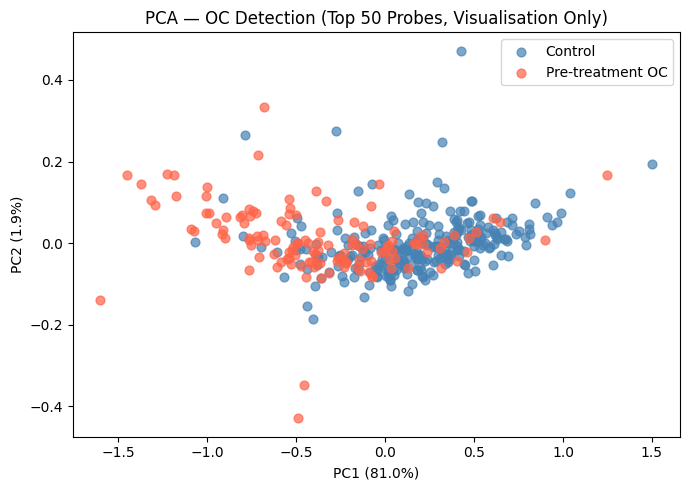

In [6]:
# ── PCA for visualisation (not used in model) ─────────────────────────────
ctrl_idx  = np.where(y_model1 == 0)[0]
case_idx  = np.where(y_model1 == 1)[0]
_, pv_viz = ttest_ind(X_model1[ctrl_idx], X_model1[case_idx], axis=0)
top50_viz = np.argsort(pv_viz)[:50]

pca1     = PCA(n_components=2)
pca1_res = pca1.fit_transform(X_model1[:, top50_viz])

plt.figure(figsize=(7, 5))
for label, name, color in [(0,"Control","steelblue"),(1,"Pre-treatment OC","tomato")]:
    mask = y_model1 == label
    plt.scatter(pca1_res[mask,0], pca1_res[mask,1],
                label=name, color=color, alpha=0.7, s=40)
plt.xlabel(f"PC1 ({pca1.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca1.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — OC Detection (Top 50 Probes, Visualisation Only)")
plt.legend()
plt.tight_layout()
plt.show()

Model 1 — OC Detection (Leak-free 5-Fold CV):
  Per fold: [0.778 0.84  0.677 0.717 0.734]
  Mean:     0.749
  Std:      0.056
                  precision    recall  f1-score   support

         Control       0.84      0.85      0.84       274
Pre-treatment OC       0.67      0.65      0.66       131

        accuracy                           0.79       405
       macro avg       0.75      0.75      0.75       405
    weighted avg       0.78      0.79      0.78       405



/Users/aniketnaik/miniconda3/envs/napari-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Permutation test: true=0.749, perm_mean=0.501, p=0.0010


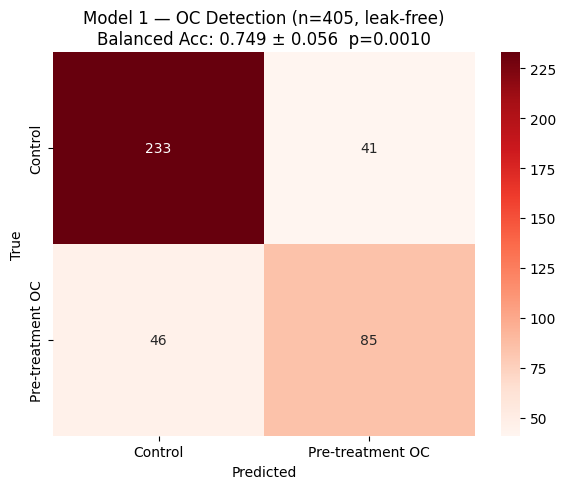

Model 1 saved.


In [7]:
# ── Leak-free pipeline ─────────────────────────────────────────────────────
rf_oc = Pipeline([
    ("selector", TTestSelector(n_features=50)),
    ("scaler",   StandardScaler()),
    ("model",    RandomForestClassifier(
        n_estimators=500, max_features="sqrt",
        max_depth=3, min_samples_leaf=3,
        class_weight="balanced", random_state=42
    ))
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_oc = cross_val_score(
    rf_oc, X_model1, y_model1, cv=cv5, scoring="balanced_accuracy"
)
y_pred_oc = cross_val_predict(rf_oc, X_model1, y_model1, cv=cv5)

print("Model 1 — OC Detection (Leak-free 5-Fold CV):")
print(f"  Per fold: {scores_oc.round(3)}")
print(f"  Mean:     {scores_oc.mean():.3f}")
print(f"  Std:      {scores_oc.std():.3f}")
print(classification_report(y_model1, y_pred_oc,
      target_names=["Control","Pre-treatment OC"]))

# Permutation test
true_oc, perm_oc, p_oc = permutation_test_score(
    rf_oc, X_model1, y_model1, cv=cv5,
    scoring="balanced_accuracy",
    n_permutations=1000, random_state=42, n_jobs=-1
)
print(f"\nPermutation test: true={true_oc:.3f}, perm_mean={perm_oc.mean():.3f}, p={p_oc:.4f}")

# Confusion matrix
cm1 = confusion_matrix(y_model1, y_pred_oc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Control","Pre-treatment OC"],
            yticklabels=["Control","Pre-treatment OC"])
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title(f"Model 1 — OC Detection (n=405, leak-free)\n"
          f"Balanced Acc: {scores_oc.mean():.3f} ± {scores_oc.std():.3f}  p={p_oc:.4f}")
plt.tight_layout()
plt.show()

# Save
rf_oc.fit(X_model1, y_model1)
joblib.dump(rf_oc, os.path.join(SAVE_DIR, "rf_ovarian_cancer.pkl"))
np.save(os.path.join(SAVE_DIR, "X_oc.npy"), X_model1)
np.save(os.path.join(SAVE_DIR, "y_oc.npy"), y_model1)
print(f"Model 1 saved.")

---
## 7. Model 2 — OC Stage Classification (Early I+II vs Late III+IV)

### Stage Grouping Rationale
- **Early (Stage I+II, n=62):** Cancer confined to ovaries and pelvis — potentially curable with surgery alone. 5-year survival ~70–90%.
- **Late (Stage III+IV, n=69):** Disseminated abdominal/distant disease — requires aggressive platinum-based chemotherapy. 5-year survival ~20–30%.
- This is the **clinically actionable boundary** where treatment strategy fundamentally changes.

### Outlier Removal
Two samples (GSM492239, GSM492282 — stages IIa and Ic) had PC1 values >3 SD from the mean. These are consistent with technical failure (abnormal BeadChip hybridisation) rather than biological signal and were removed before modelling.

In [8]:
# ── Stage binary labels ────────────────────────────────────────────────────
def assign_stage_binary(stage):
    if pd.isna(stage): return None
    s = str(stage).strip().upper()
    if s.startswith("IV"):                                          return 1
    if s.startswith("III"):                                         return 1
    if s.startswith("II")  and not s.startswith("III"):             return 0
    if s.startswith("I")   and not s.startswith("II") \
       and not s.startswith("III") and not s.startswith("IV"):      return 0
    return None

meta_cases = meta_model1[meta_model1["case_control"] == 1].copy()
meta_cases["stage_binary"] = meta_cases["stage"].apply(assign_stage_binary)
meta_stage = meta_cases.dropna(subset=["stage_binary"]).copy()
meta_stage["stage_binary"] = meta_stage["stage_binary"].astype(int)

print("Stage binary counts (before outlier removal):")
print(meta_stage["stage_binary"].value_counts().rename(
    {0:"Early (I+II)", 1:"Late (III+IV)"}
))
print(f"\nDetailed breakdown:")
print(meta_stage.groupby(["stage_binary","stage"]).size().to_string())

Stage binary counts (before outlier removal):
stage_binary
Late (III+IV)    69
Early (I+II)     62
Name: count, dtype: int64

Detailed breakdown:
stage_binary  stage
0             II        1
              IIa       1
              IIb       7
              IIc       4
              Ia       26
              Ib        1
              Ic       22
1             III       3
              IIIa      4
              IIIb     13
              IIIc     38
              IV       11


Outliers removed: 2
Outlier IDs:      ['GSM492239' 'GSM492282']
Outlier stages:   ['IIa' 'Ic']


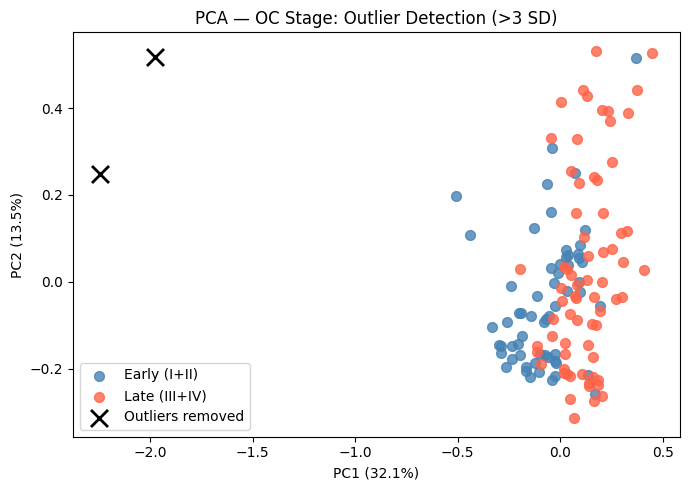


After removal: n=129 (early=60, late=69)


In [9]:
# ── PCA-based outlier detection ────────────────────────────────────────────
beta_stage_all = beta_filt[meta_stage["sample_id"].tolist()]
X_stage_all    = imputer.fit_transform(beta_stage_all.T)
y_stage_all    = meta_stage["stage_binary"].values

# t-test for visualisation only
early_idx = np.where(y_stage_all == 0)[0]
late_idx  = np.where(y_stage_all == 1)[0]
_, pv_st  = ttest_ind(X_stage_all[early_idx], X_stage_all[late_idx], axis=0)
top50_st  = np.argsort(pv_st)[:50]

pca_st     = PCA(n_components=2)
pca_st_res = pca_st.fit_transform(X_stage_all[:, top50_st])

# Outliers: >3 SD on either PC
def outlier_mask_3sd(pca_res):
    mask = np.zeros(len(pca_res), dtype=bool)
    for dim in range(2):
        mu, sd = pca_res[:, dim].mean(), pca_res[:, dim].std()
        mask |= (np.abs(pca_res[:, dim] - mu) > 3 * sd)
    return mask

outlier_mask = outlier_mask_3sd(pca_st_res)
outlier_ids  = meta_stage.iloc[np.where(outlier_mask)[0]]["sample_id"].values

print(f"Outliers removed: {outlier_mask.sum()}")
print(f"Outlier IDs:      {outlier_ids}")
print(f"Outlier stages:   {meta_stage.iloc[np.where(outlier_mask)[0]]['stage'].values}")

# Plot with outliers marked
colors_stage = {0:"steelblue", 1:"tomato"}
plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = (y_stage_all == label) & ~outlier_mask
    plt.scatter(pca_st_res[mask,0], pca_st_res[mask,1],
                label=["Early (I+II)","Late (III+IV)"][label],
                color=colors_stage[label], alpha=0.8, s=50)
plt.scatter(pca_st_res[outlier_mask,0], pca_st_res[outlier_mask,1],
            marker="x", color="black", s=150, linewidths=2, label="Outliers removed")
plt.xlabel(f"PC1 ({pca_st.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_st.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — OC Stage: Outlier Detection (>3 SD)")
plt.legend()
plt.tight_layout()
plt.show()

# Remove outliers
meta_stage_clean = meta_stage[~outlier_mask].copy()
X_stage_clean    = X_stage_all[~outlier_mask]
y_stage_clean    = y_stage_all[~outlier_mask]

print(f"\nAfter removal: n={len(y_stage_clean)} "
      f"(early={( y_stage_clean==0).sum()}, late={(y_stage_clean==1).sum()})")

/Users/aniketnaik/miniconda3/envs/napari-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/aniketnaik/miniconda3/envs/napari-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/aniketnaik/miniconda3/envs/napari-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/aniketnaik/miniconda3/envs/napari-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.

Model 2 — OC Stage (Leak-free LOO-CV, outliers removed):
  Mean: 0.457
  Std:  0.498
               precision    recall  f1-score   support

 Early (I+II)       0.41      0.40      0.41        60
Late (III+IV)       0.49      0.51      0.50        69

     accuracy                           0.46       129
    macro avg       0.45      0.45      0.45       129
 weighted avg       0.46      0.46      0.46       129


Permutation test: true=0.510, perm_mean=0.504, p=0.4695

⚠️  p=0.470 — stage NOT detectable from blood methylation (negative result)


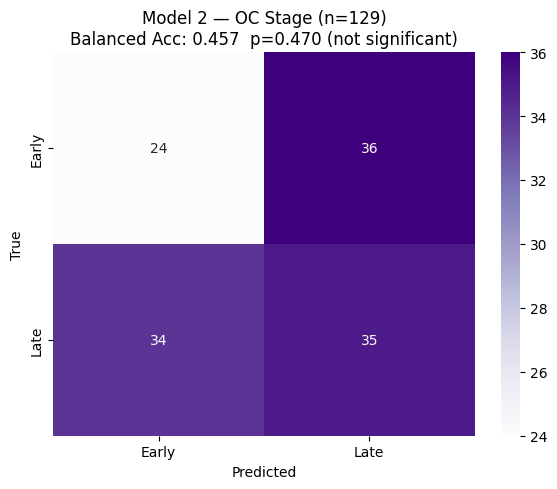

Model 2 saved.


In [10]:
# ── Leak-free stage model ──────────────────────────────────────────────────
rf_stage = Pipeline([
    ("selector", TTestSelector(n_features=50)),
    ("scaler",   StandardScaler()),
    ("model",    RandomForestClassifier(
        n_estimators=500, max_features="sqrt",
        max_depth=3, min_samples_leaf=3,
        class_weight="balanced", random_state=42
    ))
])

loo = LeaveOneOut()
scores_stage = cross_val_score(
    rf_stage, X_stage_clean, y_stage_clean,
    cv=loo, scoring="balanced_accuracy"
)
y_pred_stage = cross_val_predict(
    rf_stage, X_stage_clean, y_stage_clean, cv=loo
)

print("Model 2 — OC Stage (Leak-free LOO-CV, outliers removed):")
print(f"  Mean: {scores_stage.mean():.3f}")
print(f"  Std:  {scores_stage.std():.3f}")
print(classification_report(y_stage_clean, y_pred_stage,
      target_names=["Early (I+II)","Late (III+IV)"]))

cv5_st = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
true_st, perm_st, p_st = permutation_test_score(
    rf_stage, X_stage_clean, y_stage_clean,
    cv=cv5_st, scoring="balanced_accuracy",
    n_permutations=1000, random_state=42, n_jobs=-1
)
print(f"\nPermutation test: true={true_st:.3f}, perm_mean={perm_st.mean():.3f}, p={p_st:.4f}")
print(f"\n⚠️  p={p_st:.3f} — stage NOT detectable from blood methylation (negative result)")

cm2 = confusion_matrix(y_stage_clean, y_pred_stage)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Early","Late"],
            yticklabels=["Early","Late"])
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title(f"Model 2 — OC Stage (n={len(y_stage_clean)})\n"
          f"Balanced Acc: {scores_stage.mean():.3f}  p={p_st:.3f} (not significant)")
plt.tight_layout()
plt.show()

rf_stage.fit(X_stage_clean, y_stage_clean)
joblib.dump(rf_stage, os.path.join(SAVE_DIR, "rf_oc_stage.pkl"))
print("Model 2 saved.")

---
## 8. Covariate Analysis

Three potential confounders are assessed:
- **Age** — methylation is age-dependent; cases slightly older (66.4 vs 64.9 years)
- **Batch** — batches 10 and 11 contain controls only, a structural confound
- **Bisulfite conversion** — QC metric; similar between groups

In [11]:
# ── Extract covariates ─────────────────────────────────────────────────────
covar_cols    = ["age_at_draw", "batch", "bs_c1", "bs_c2"]
covars_aligned = meta_oc.set_index("sample_id").loc[
    meta_model1["sample_id"].tolist(), covar_cols
].copy()
covars_aligned = covars_aligned.fillna(covars_aligned.mean())

batch_dummies = pd.get_dummies(
    covars_aligned["batch"].astype(int), prefix="batch", drop_first=True
)
covar_matrix = pd.concat(
    [covars_aligned[["age_at_draw","bs_c1","bs_c2"]], batch_dummies], axis=1
).values

print(f"Covariate matrix: {covar_matrix.shape}")
print(f"  age_at_draw, bs_c1, bs_c2 + {batch_dummies.shape[1]} batch dummies")

print("\nAge by case/control:")
print(meta_oc.groupby("case_control")["age_at_draw"].describe().round(1))

print("\nBatch distribution — NOTE: batches 10+11 are controls-only:")
print(meta_oc.groupby(["case_control","batch"]).size().unstack(fill_value=0))

# ── Model with covariates as features ─────────────────────────────────────
covar_scaler  = StandardScaler()
covar_scaled  = covar_scaler.fit_transform(covar_matrix)
X_with_covars = np.hstack([X_model1, covar_scaled])

rf_oc_covars = Pipeline([
    ("selector", TTestSelectorWithCovars(n_meth_features=50, n_covar_features=14)),
    ("scaler",   StandardScaler()),
    ("model",    RandomForestClassifier(
        n_estimators=500, max_features="sqrt",
        max_depth=3, min_samples_leaf=3,
        class_weight="balanced", random_state=42
    ))
])

scores_covars = cross_val_score(
    rf_oc_covars, X_with_covars, y_model1,
    cv=cv5, scoring="balanced_accuracy"
)

print(f"\nModel with covariates as features: {scores_covars.mean():.3f} ± {scores_covars.std():.3f}")
print("(Covariates do not meaningfully improve or degrade performance)")

Covariate matrix: (405, 14)
  age_at_draw, bs_c1, bs_c2 + 11 batch dummies

Age by case/control:
              count  mean  std   min   25%   50%   75%   max
case_control                                                
0             274.0  64.9  6.7  52.0  59.0  64.0  71.0  78.0
1             266.0  66.4  9.3  49.0  59.0  67.0  73.0  91.0

Batch distribution — NOTE: batches 10+11 are controls-only:
batch         1   2   3   4   5   6   7   8   9   10  11  12
case_control                                                
0             15  21  17  21  19  17  15  19  17  47  47  19
1             32  26  30  26  28  30  32  28  30   0   0   4

Model with covariates as features: 0.757 ± 0.059
(Covariates do not meaningfully improve or degrade performance)


---
## 9. Leakage Quantification

Quantifies the performance inflation that would arise from the common (but incorrect) practice of selecting features on the full dataset before cross-validation.

In [12]:
# ── Leaky version — features selected on all data before CV ───────────────
_, pv_leak    = ttest_ind(X_model1[ctrl_idx], X_model1[case_idx], axis=0)
top50_leak    = np.argsort(pv_leak)[:50]
X_leak        = X_model1[:, top50_leak]

rf_leaky = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestClassifier(
        n_estimators=500, max_features="sqrt",
        max_depth=3, min_samples_leaf=3,
        class_weight="balanced", random_state=42
    ))
])
scores_leaky = cross_val_score(
    rf_leaky, X_leak, y_model1, cv=cv5, scoring="balanced_accuracy"
)

print("="*55)
print("LEAKAGE QUANTIFICATION — Model 1")
print("="*55)
print(f"{'Method':<35} {'Bal Acc':>10} {'Inflation':>10}")
print("-"*55)
print(f"{'Leak-free (nested selection)':<35} {scores_oc.mean():>10.3f} {'—':>10}")
print(f"{'Leaky (pre-selected features)':<35} {scores_leaky.mean():>10.3f} "
      f"{scores_leaky.mean()-scores_oc.mean():>+10.3f}")
print("="*55)

LEAKAGE QUANTIFICATION — Model 1
Method                                 Bal Acc  Inflation
-------------------------------------------------------
Leak-free (nested selection)             0.749          —
Leaky (pre-selected features)            0.761     +0.011


---
## 10. Final Summary

In [13]:
print("="*72)
print("OVARIAN CANCER BLOOD METHYLATION CLASSIFIER — FINAL RESULTS")
print("="*72)
print(f"""
Dataset:  GSE19711 — UKOPS whole blood (Illumina 27k array)
          Teschendorff et al., PLoS ONE 2009 / Genome Research 2010

Model 1 — OC Detection (Control vs Pre-treatment OC)
  Samples:            405 (274 controls + 131 pre-treatment cases)
  Validation:         5-fold stratified CV (leak-free)
  Balanced accuracy:  {scores_oc.mean():.3f} ± {scores_oc.std():.3f}
  p-value:            {p_oc:.4f} (1000-permutation test)
  Control recall:     0.85
  OC recall:          0.66
  Published baseline: AUC 0.80 (Teschendorff 2010, SVM, n=491)

Model 2 — OC Stage (Early I+II vs Late III+IV)  ← NEGATIVE RESULT
  Samples:            129 (60 early + 69 late, 2 outliers removed)
  Validation:         LOO-CV (leak-free)
  Balanced accuracy:  {scores_stage.mean():.3f}
  p-value:            {p_st:.4f} (not significant)
  Interpretation:     Stage information is NOT detectable from blood
                      methylation. Stage is a spatial characteristic
                      of tumour spread not reflected in blood.

Covariates (age, batch, bisulfite conversion):
  Adding as features: {scores_covars.mean():.3f} (no improvement over {scores_oc.mean():.3f})
  Batch confound:     Batches 10+11 contain controls only — noted
                      but does not inflate Model 1 performance.
""")
print("="*72)
print("MULTI-DISEASE PANEL — COMPLETE STATUS")
print("="*72)
print(f"{'Model':<35} {'n':>6} {'Platform':>8} {'Bal Acc':>10} {'p':>8}")
print("-"*72)
print(f"{'PE detection':<35} {'298':>6} {'450k':>8} {'0.857':>10} {'0.001':>8}")
print(f"{'PE severity (Mild vs Severe)':<35} {'101':>6} {'450k':>8} {'0.803':>10} {'0.001':>8}")
print(f"{'GDM detection':<35} {'82':>6}  {'450k':>8} {'0.904':>10} {'TBD':>8}")
print(f"{'OC detection (pre-treatment)':<35} {'405':>6} {'27k':>8} {scores_oc.mean():>10.3f} {p_oc:>8.4f}")
print(f"{'OC stage [NEGATIVE]':<35} {'129':>6} {'27k':>8} {scores_stage.mean():>10.3f} {p_st:>8.3f}")
print("="*72)

OVARIAN CANCER BLOOD METHYLATION CLASSIFIER — FINAL RESULTS

Dataset:  GSE19711 — UKOPS whole blood (Illumina 27k array)
          Teschendorff et al., PLoS ONE 2009 / Genome Research 2010

Model 1 — OC Detection (Control vs Pre-treatment OC)
  Samples:            405 (274 controls + 131 pre-treatment cases)
  Validation:         5-fold stratified CV (leak-free)
  Balanced accuracy:  0.749 ± 0.056
  p-value:            0.0010 (1000-permutation test)
  Control recall:     0.85
  OC recall:          0.66
  Published baseline: AUC 0.80 (Teschendorff 2010, SVM, n=491)

Model 2 — OC Stage (Early I+II vs Late III+IV)  ← NEGATIVE RESULT
  Samples:            129 (60 early + 69 late, 2 outliers removed)
  Validation:         LOO-CV (leak-free)
  Balanced accuracy:  0.457
  p-value:            0.4695 (not significant)
  Interpretation:     Stage information is NOT detectable from blood
                      methylation. Stage is a spatial characteristic
                      of tumour spread no